# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 1 — Major Project 2026–2027

**Student Name:** [Student Name]  
**College Name:** [College Name]  
**AICTE STU ID:** [AICTE STU ID]

This notebook analyzes seasonal agricultural performance across **Kharif, Rabi, and Zaid** using environmental conditions, resource utilization, crop production, water efficiency, and economic outcomes.

## 1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. Raw data does not directly reveal how agricultural performance changes across seasons.

The project therefore investigates meaningful **patterns, trends, relationships, and differences** in agricultural performance across Kharif, Rabi, and Zaid seasons.

## 2. Objectives
1. Explore and understand the dataset.
2. Clean and prepare the data for analysis.
3. Compare yield, production, profitability, resource use, and risk across seasons.
4. Examine crop × season, irrigation, and regional differences.
5. Investigate relationships between environmental conditions and agricultural outcomes.
6. Apply statistical tests and visualization techniques.
7. Develop evidence-based findings and recommendations.

## 3. Key Analytical Questions
- Which season has the highest yield and profitability?
- How do rainfall, temperature, soil moisture, and risk change by season?
- Which crop–season combinations perform best economically?
- How does irrigation method relate to yield and water efficiency?
- Are seasonal performance differences statistically significant?
- Which variables show the strongest relationships with yield and profit?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import kruskal

DATA_PATH = Path('seasonal_agriculture_performance_dataset.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 4. Load the Dataset

In [2]:
df = pd.read_csv(DATA_PATH)
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 5. Dataset Structure and Data Quality

In [3]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('Exact duplicate rows:', df.duplicated().sum())
print('\nSeason counts:')
print(df['Season'].value_counts())
print('\nCrop counts:')
print(df['Crop'].value_counts())

Rows: 4000
Columns: 28
Exact duplicate rows: 0

Season counts:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crop counts:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


In [4]:
missing_before = df.isna().sum()
missing_before[missing_before > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

### Initial data-quality findings
- **4,000 records** and **28 variables**.
- **No exact duplicate rows**.
- Missing values: **48 rainfall**, **40 soil moisture**, and **32 yield** values.
- The dataset covers **3 seasons, 8 crops, and 8 states**.

## 6. Data Cleaning

In [5]:
clean = df.copy()

# Environmental variables: impute with the median of the same season.
for col in ['Rainfall_mm', 'Soil_Moisture_pct']:
    clean[col] = clean.groupby('Season')[col].transform(
        lambda s: s.fillna(s.median())
    )

# Yield can be reconstructed because Production ≈ Yield × Farm Area.
mask_yield = clean['Yield_Tonnes_Ha'].isna()
clean.loc[mask_yield, 'Yield_Tonnes_Ha'] = (
    clean.loc[mask_yield, 'Production_Tonnes'] /
    clean.loc[mask_yield, 'Farm_Area_Hectares']
).round(2)

clean = clean.drop_duplicates().copy()
clean['Profit_Margin_pct'] = np.where(
    clean['Revenue_INR'] != 0,
    clean['Profit_INR'] / clean['Revenue_INR'] * 100,
    np.nan
)

print('Remaining missing values:', clean.isna().sum().sum())
print('Rows after cleaning:', len(clean))

Remaining missing values: 0
Rows after cleaning: 4000


### Cleaning rationale
Season-specific medians preserve seasonal context for rainfall and soil moisture. Missing yield values are **derived from production ÷ farm area**, which is more defensible than arbitrary imputation because production is mathematically linked to yield in this dataset.

## 7. Seasonal Composition

In [6]:
season_counts = clean['Season'].value_counts().reindex(['Kharif','Rabi','Zaid'])
season_counts

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

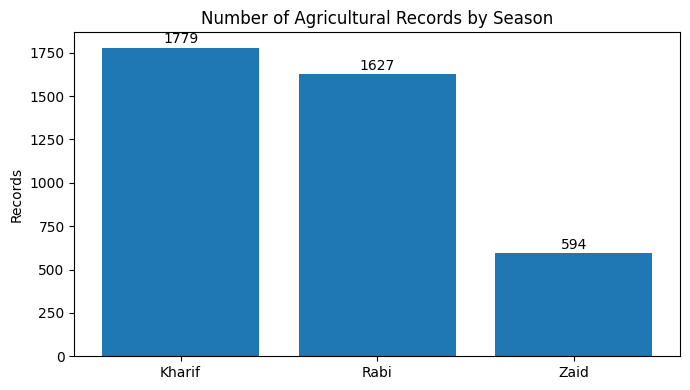

In [7]:
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(season_counts.index, season_counts.values)
ax.set_title('Number of Agricultural Records by Season')
ax.set_ylabel('Records')
for i,v in enumerate(season_counts.values):
    ax.text(i, v+25, str(v), ha='center')
plt.tight_layout(); plt.show()

## 8. Seasonal Performance Summary

In [8]:
season_summary = clean.groupby('Season').agg(
    Records=('Farm_ID','count'),
    Avg_Yield=('Yield_Tonnes_Ha','mean'),
    Median_Yield=('Yield_Tonnes_Ha','median'),
    Avg_Production=('Production_Tonnes','mean'),
    Avg_Rainfall=('Rainfall_mm','mean'),
    Avg_Temperature=('Avg_Temperature_C','mean'),
    Avg_Humidity=('Humidity_pct','mean'),
    Avg_Soil_Moisture=('Soil_Moisture_pct','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Median_Profit=('Profit_INR','median'),
    Avg_Risk=('Disease_Pest_Risk_pct','mean')
).round(2)
season_summary

,Records,Avg_Yield,Median_Yield,Avg_Production,Avg_Rainfall,Avg_Temperature,Avg_Humidity,Avg_Soil_Moisture,Avg_Water_Efficiency,Avg_Profit,Median_Profit,Avg_Risk
Season,,,,,,,,,,,,
Kharif,1779,5.63,1.94,46.31,852.11,28.45,71.81,31.20,5.89,"178,914.65","38,808.00",54.47
Rabi,1627,5.09,1.66,41.49,435.94,23.49,57.89,24.05,5.19,"87,689.47","-3,187.00",40.48
Zaid,594,4.63,1.45,38.89,299.12,31.04,52.01,19.17,4.41,"-24,804.82","-62,144.00",38.22


### Seasonal performance insight
- **Kharif** has the highest average yield (**5.63 t/ha**) and median yield (**1.94 t/ha**).
- Average profit is highest in **Kharif (₹178,915)**, followed by **Rabi (₹87,689)**.
- **Zaid average profit is negative (₹-24,805)**, indicating weaker economics in the dataset overall.
- Mean yield is much higher than median yield because high-yield crops such as sugarcane create a strongly skewed distribution.

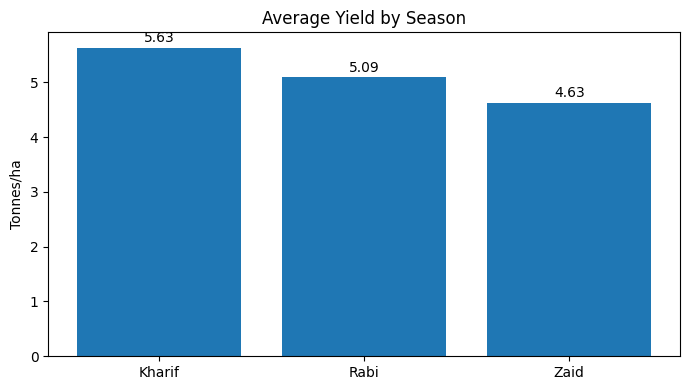

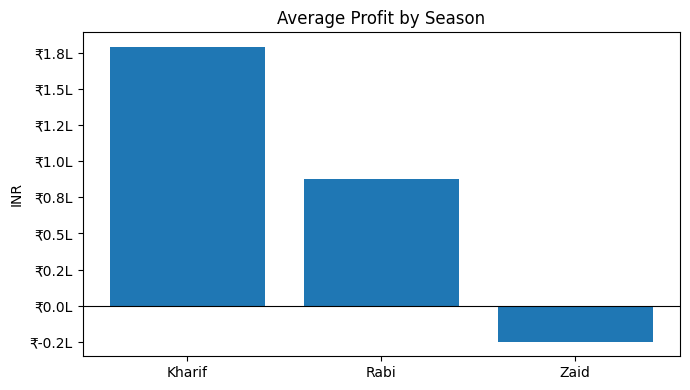

In [9]:
order=['Kharif','Rabi','Zaid']
fig, ax = plt.subplots(figsize=(7,4))
vals = season_summary.reindex(order)['Avg_Yield']
ax.bar(order, vals)
ax.set_title('Average Yield by Season'); ax.set_ylabel('Tonnes/ha')
for i,v in enumerate(vals): ax.text(i,v+.1,f'{v:.2f}',ha='center')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7,4))
vals = season_summary.reindex(order)['Avg_Profit']
ax.bar(order, vals)
ax.axhline(0,color='black',lw=.8)
ax.set_title('Average Profit by Season'); ax.set_ylabel('INR')
ax.yaxis.set_major_formatter(FuncFormatter(lambda y,_: f'₹{y/100000:.1f}L'))
plt.tight_layout(); plt.show()

## 9. Environmental Conditions Across Seasons

In [10]:
environment_summary = clean.groupby('Season')[
    ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct','Disease_Pest_Risk_pct']
].mean().round(2)
environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Disease_Pest_Risk_pct
Season,,,,,
Kharif,852.11,28.45,71.81,31.20,54.47
Rabi,435.94,23.49,57.89,24.05,40.48
Zaid,299.12,31.04,52.01,19.17,38.22


### Environmental findings
- **Kharif is the wettest season**: average rainfall **852.1 mm**, humidity **71.8%**, and soil moisture **31.2%**.
- **Zaid is the hottest and driest**: average temperature **31.0°C** and soil moisture **19.2%**.
- Disease/pest risk is highest in Kharif (**54.5%**), suggesting that higher-moisture conditions coincide with greater risk in this dataset.

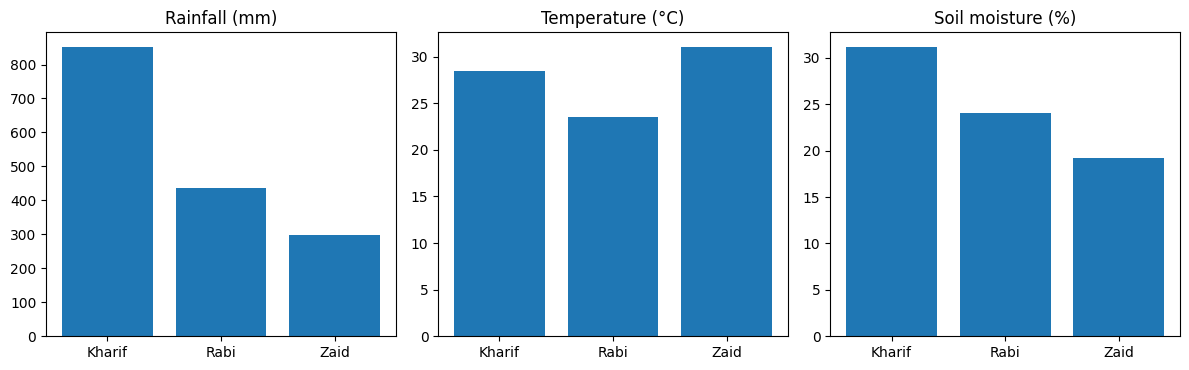

In [11]:
fig, axes = plt.subplots(1,3,figsize=(12,3.8))
for ax, col, title in [
    (axes[0],'Rainfall_mm','Rainfall (mm)'),
    (axes[1],'Avg_Temperature_C','Temperature (°C)'),
    (axes[2],'Soil_Moisture_pct','Soil moisture (%)')
]:
    vals=clean.groupby('Season')[col].mean().reindex(order)
    ax.bar(order,vals); ax.set_title(title)
plt.tight_layout(); plt.show()

## 10. Resource Usage and Water Efficiency

In [12]:
resource_summary = clean.groupby('Season')[
    ['Fertilizer_kg_ha','Pesticide_Litre_ha','Water_Used_m3','Water_Efficiency_t_per_1000m3']
].mean().round(2)
resource_summary

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,"6,102.20",5.89
Rabi,185.41,5.02,"5,846.99",5.19
Zaid,184.64,5.17,"6,419.89",4.41


### Resource findings
Fertilizer and pesticide usage are relatively similar across seasons, while water outcomes differ more clearly. Average water efficiency is **5.89**, **5.19**, and **4.41 t per 1000 m³** for Kharif, Rabi, and Zaid respectively.

## 11. Crop × Season Analysis

In [13]:
crop_season = clean.groupby(['Season','Crop']).agg(
    Records=('Farm_ID','count'),
    Avg_Yield=('Yield_Tonnes_Ha','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean')
).round(2)

crop_season.sort_values('Avg_Profit',ascending=False).head(10)

Records  Avg_Yield   Avg_Profit  Avg_Water_Efficiency
Season Crop                                                            
Kharif Sugarcane      125      53.46 1,000,790.81                 36.00
       Chilli         185       1.73   954,380.42                  3.26
Rabi   Sugarcane      129      43.95   731,612.86                 27.92
       Chilli         163       1.46   638,572.50                  2.89
Zaid   Sugarcane       51      38.42   583,635.80                 23.39
       Chilli          64       1.18   448,659.09                  2.20
Kharif Cotton         215       1.37   216,999.55                  2.13
       Groundnut      193       1.48   108,265.44                  3.58
Rabi   Cotton         201       1.19   107,343.59                  1.94
Kharif Pulses         221       1.04    43,338.90                  3.35

### Crop–season findings
- **Kharif Sugarcane** is the strongest crop–season group by average profit in the dataset: approximately **₹1,000,791** per record and **53.46 t/ha** average yield.
- Chilli is also highly profitable despite much lower physical yield, showing that **market value matters as much as tonnage**.
- Several maize, rice, wheat, and Zaid combinations have negative average profit, so yield alone should not be used for planning.

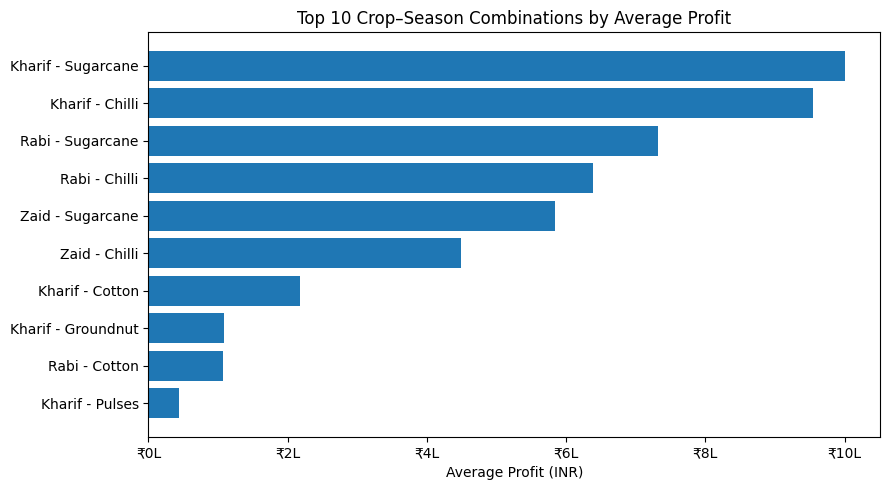

In [14]:
top = crop_season.reset_index().sort_values('Avg_Profit',ascending=False).head(10)
labels = top['Season'] + ' - ' + top['Crop']
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(labels[::-1], top['Avg_Profit'][::-1])
ax.set_title('Top 10 Crop–Season Combinations by Average Profit')
ax.set_xlabel('Average Profit (INR)')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x,_: f'₹{x/100000:.0f}L'))
plt.tight_layout(); plt.show()

## 12. Irrigation Method Analysis

In [15]:
irrigation_summary = clean.groupby(['Season','Irrigation_Method']).agg(
    Avg_Yield=('Yield_Tonnes_Ha','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean')
).round(2)
irrigation_summary

Avg_Yield  Avg_Profit  Avg_Water_Efficiency
Season Irrigation_Method                                             
Kharif Drip                    7.26  317,222.07                  6.80
       Flood                   4.98  133,373.83                  3.64
       Rainfed                 5.70  158,974.13                  8.85
       Sprinkler               4.67  116,880.49                  4.62
Rabi   Drip                    6.35  187,843.22                  6.05
       Flood                   5.06   58,824.80                  3.48
       Rainfed                 3.93   45,232.48                  6.87
       Sprinkler               5.30   76,502.07                  4.64
Zaid   Drip                    5.85   21,291.84                  5.30
       Flood                   3.97  -69,786.78                  2.73
       Rainfed                 3.06  -79,467.26                  5.48
       Sprinkler               6.13   57,909.40                  4.86

### Irrigation findings
- **Drip irrigation** records the highest average yield and profit within both Kharif and Rabi.
- **Sprinkler irrigation** has the highest average yield and profit in Zaid.
- Rainfed observations show high calculated water-efficiency values, which should be interpreted carefully because the denominator represents measured water use and may be lower for rainfed farms.

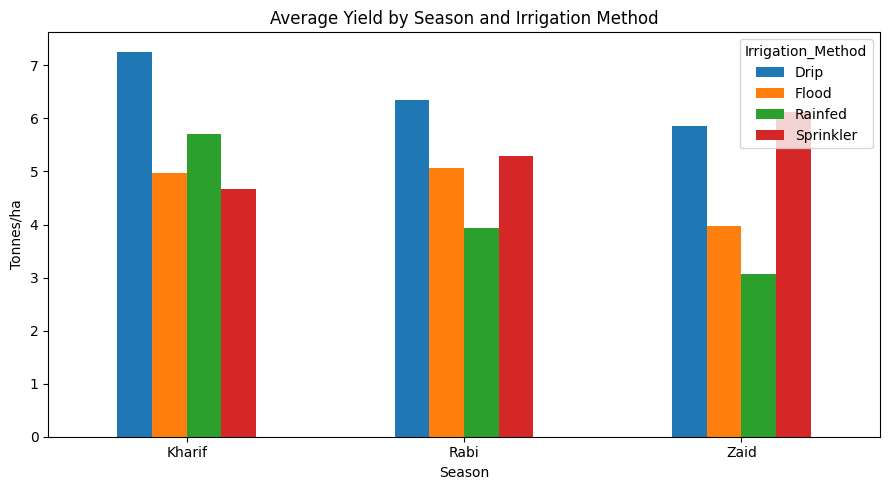

In [16]:
pivot = irrigation_summary['Avg_Yield'].unstack('Irrigation_Method').reindex(order)
pivot.plot(kind='bar',figsize=(9,5))
plt.title('Average Yield by Season and Irrigation Method')
plt.ylabel('Tonnes/ha'); plt.xlabel('Season'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 13. Regional Analysis

In [17]:
state_performance = clean.groupby('State').agg(
    Records=('Farm_ID','count'),
    Avg_Yield=('Yield_Tonnes_Ha','mean'),
    Avg_Profit=('Profit_INR','mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3','mean')
).round(2).sort_values('Avg_Profit',ascending=False)
state_performance

,Records,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
State,,,,
Punjab,484,6.12,"136,025.64",5.62
Maharashtra,512,5.01,"135,428.86",5.28
Karnataka,489,5.75,"119,422.34",5.56
Tamil Nadu,485,4.87,"117,744.75",5.31
Gujarat,488,5.76,"117,568.24",5.58
Telangana,516,5.05,"108,829.62",5.46
Madhya Pradesh,497,4.98,"86,840.76",5.27
Andhra Pradesh,529,4.63,"73,453.53",5.03


### Regional observation
In the supplied dataset, **Punjab** has the highest average profit (**₹136,026**), while state-level differences indicate that seasonal recommendations should not be assumed to be identical across regions.

## 14. Correlation Analysis

In [18]:
corr_cols = [
    'Rainfall_mm','Avg_Temperature_C','Humidity_pct','Soil_Moisture_pct',
    'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score',
    'Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]
corr = clean[corr_cols].corr()
corr.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,1.00,0.20,0.53,0.52,0.02,0.00,-0.02,0.03,0.11,0.06,0.62
Avg_Temperature_C,0.20,1.00,0.14,0.08,0.02,0.01,-0.03,0.01,0.01,0.01,0.25
Humidity_pct,0.53,0.14,1.00,0.45,0.02,-0.00,-0.05,0.01,0.06,0.03,0.55
Soil_Moisture_pct,0.52,0.08,0.45,1.00,0.01,-0.02,-0.02,0.01,0.09,0.03,0.38
Fertilizer_kg_ha,0.02,0.02,0.02,0.01,1.00,-0.00,0.02,-0.00,-0.07,0.01,0.02
Pesticide_Litre_ha,0.00,0.01,-0.00,-0.02,-0.00,1.00,-0.00,-0.01,-0.03,-0.01,-0.47
Seed_Quality_Score,-0.02,-0.03,-0.05,-0.02,0.02,-0.00,1.00,-0.01,0.01,-0.01,-0.02
Yield_Tonnes_Ha,0.03,0.01,0.01,0.01,-0.00,-0.01,-0.01,1.00,0.49,0.92,0.01
Profit_INR,0.11,0.01,0.06,0.09,-0.07,-0.03,0.01,0.49,1.00,0.49,0.07
Water_Efficiency_t_per_1000m3,0.06,0.01,0.03,0.03,0.01,-0.01,-0.01,0.92,0.49,1.00,0.03


### Correlation findings
- Yield has a **very strong positive association with water efficiency** (**r = 0.916**).
- Yield and profit have a **moderate positive association** (**r = 0.490**).
- Rainfall has only a weak overall linear relationship with yield (**r = 0.027**). This does **not** mean rainfall is unimportant; crop mix and seasonal structure can mask simple linear relationships.

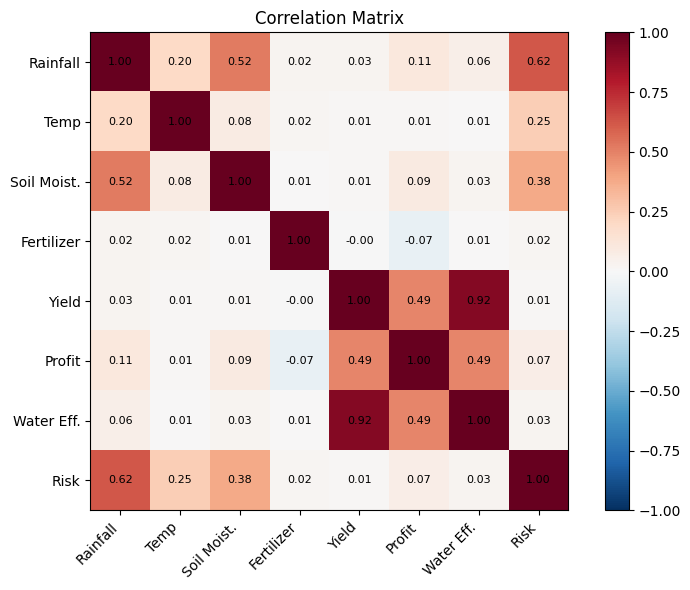

In [19]:
focus=['Rainfall_mm','Avg_Temperature_C','Soil_Moisture_pct','Fertilizer_kg_ha',
       'Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']
mat=clean[focus].corr()
fig, ax=plt.subplots(figsize=(8,6))
im=ax.imshow(mat.values,cmap='RdBu_r',vmin=-1,vmax=1)
labels=['Rainfall','Temp','Soil Moist.','Fertilizer','Yield','Profit','Water Eff.','Risk']
ax.set_xticks(range(len(labels)),labels,rotation=45,ha='right')
ax.set_yticks(range(len(labels)),labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j,i,f'{mat.values[i,j]:.2f}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax); ax.set_title('Correlation Matrix')
plt.tight_layout(); plt.show()

## 15. Statistical Hypothesis Testing

Because yield and profit distributions are strongly skewed across crops, the **Kruskal–Wallis test** is used as a non-parametric comparison across the three seasons.

**H₀:** The seasonal distributions are the same.  
**H₁:** At least one season differs.  
**Significance level:** α = 0.05.

In [20]:
metrics = {
    'Yield_Tonnes_Ha':'Yield',
    'Profit_INR':'Profit',
    'Water_Efficiency_t_per_1000m3':'Water efficiency',
    'Disease_Pest_Risk_pct':'Disease/pest risk'
}
results=[]
for metric,label in metrics.items():
    groups=[clean.loc[clean['Season']==s,metric].dropna() for s in order]
    h,p=kruskal(*groups)
    results.append([label,h,p,'Significant' if p<0.05 else 'Not significant'])

stat_results = pd.DataFrame(results,columns=['Metric','H statistic','p-value','Decision'])
stat_results

,Metric,H statistic,p-value,Decision
0,Yield,70.59,0.00,Significant
1,Profit,101.93,0.00,Significant
2,Water efficiency,56.81,0.00,Significant
3,Disease/pest risk,"1,430.91",0.00,Significant


### Statistical conclusion
All four Kruskal–Wallis tests are statistically significant (**p < 0.05**). The dataset therefore provides strong evidence that seasonal distributions differ for **yield, profit, water efficiency, and disease/pest risk**. Statistical significance should still be combined with the magnitude and practical relevance of the observed differences.

## 16. Outlier and Distribution Review

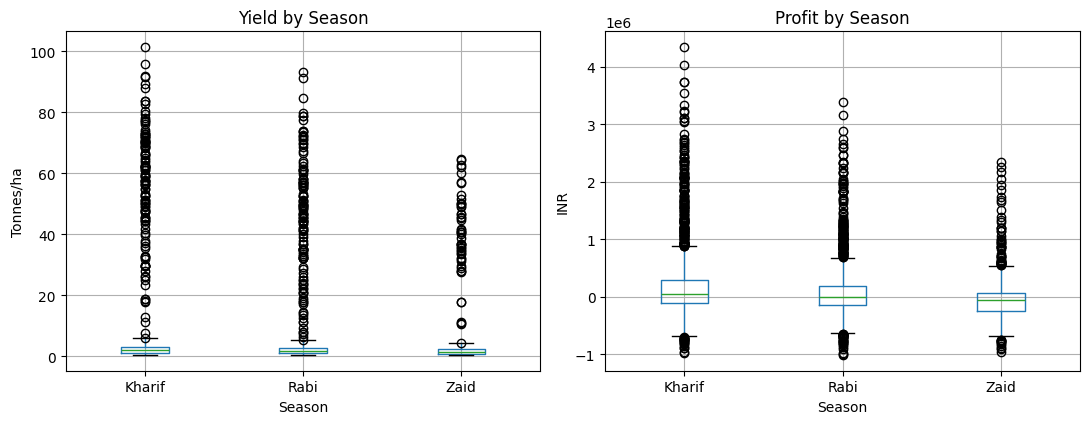

In [21]:
fig, axes=plt.subplots(1,2,figsize=(11,4.5))
clean.boxplot(column='Yield_Tonnes_Ha',by='Season',ax=axes[0])
axes[0].set_title('Yield by Season'); axes[0].set_ylabel('Tonnes/ha')
clean.boxplot(column='Profit_INR',by='Season',ax=axes[1])
axes[1].set_title('Profit by Season'); axes[1].set_ylabel('INR')
plt.suptitle(''); plt.tight_layout(); plt.show()

### Outlier interpretation
Large values are not automatically errors. Different crops have very different biological yields and market prices. For example, sugarcane naturally produces much higher tonnage than chilli or pulses. Therefore, the project retains plausible outliers and interprets them in crop context rather than deleting them automatically.

## 17. Key Findings

1. **Kharif leads overall seasonal performance** with the highest mean yield (**5.63 t/ha**) and average profit (**₹178,915**).
2. **Zaid is economically weakest overall**, with average profit of **₹-24,805**.
3. Kharif is wetter and more humid, while Zaid is hotter and drier.
4. Disease/pest risk is highest in Kharif (**54.5%**).
5. **Kharif Sugarcane** is the highest-profit crop–season group; chilli also performs strongly because of market value.
6. Drip irrigation performs strongly for yield/profit in Kharif and Rabi; sprinkler leads those metrics in Zaid.
7. Yield and water efficiency are strongly associated (**r = 0.916**), while yield and profit are moderately associated (**r = 0.490**).
8. Kruskal–Wallis tests confirm statistically significant seasonal differences in yield, profit, water efficiency, and disease/pest risk.

## 18. Recommendations

1. **Use crop–season profitability, not yield alone**, when planning seasonal production.
2. Prioritize **water-efficient irrigation** while considering local feasibility and crop requirements.
3. Strengthen **Kharif pest and disease monitoring** because risk is highest in that season.
4. Use **season-specific environmental profiles**—rainfall, temperature, and soil moisture—in crop planning.
5. Review **Zaid cost structures and crop choices**, because the season shows negative average profitability overall.
6. Develop **state- and crop-specific recommendations** rather than applying one national seasonal rule.

## 19. Limitations

- The analysis is limited to the variables and records in the supplied dataset.
- The dataset is cross-sectional; it does not represent multiple years of longitudinal performance.
- Correlation does not prove causation.
- Crop mix strongly affects overall seasonal averages.
- Real-world recommendations would also require local agronomy, market, policy, and weather validation.

## 20. Future Scope

- Add multi-year farm and weather data.
- Integrate real-time weather and satellite/remote-sensing indicators.
- Build crop-yield, profit, and pest-risk prediction models.
- Develop district-level recommendation systems.
- Build an interactive dashboard for farmers and agricultural planners.
- Add scenario analysis for climate and market-price changes.

## 21. Conclusion

The analysis shows that agricultural performance changes meaningfully across Kharif, Rabi, and Zaid. In this dataset, **Kharif has the strongest overall yield and profitability**, whereas **Zaid has the weakest average economic result**. Environmental conditions, crop choice, irrigation method, water efficiency, and market economics all contribute to seasonal outcomes.

The most useful planning approach is therefore to balance **yield + profitability + resource efficiency + risk**, rather than optimizing only one metric.

## 22. Save Cleaned Data and Summary Outputs

In [22]:
clean.to_csv(OUTPUT_DIR / 'seasonal_agriculture_performance_cleaned.csv', index=False)
season_summary.to_csv(OUTPUT_DIR / 'seasonal_summary.csv')
crop_season.to_csv(OUTPUT_DIR / 'crop_season_summary.csv')
irrigation_summary.to_csv(OUTPUT_DIR / 'irrigation_summary.csv')
stat_results.to_csv(OUTPUT_DIR / 'statistical_tests.csv', index=False)
print('Saved outputs to:', OUTPUT_DIR.resolve())

Saved outputs to: /mnt/data/Seasonal_Agriculture_Project/outputs
